[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/04_evaluation.ipynb)

# 04 — Evaluation and Method Comparison

**Inputs.** The newest finished run of each method and seed under `outputs/optim/`, the baseline radio map, and the
processed tables. **Outputs.** `reports/tables/04_evaluation/` and `reports/figures/04_evaluation/`.

No GPU is needed and nothing is re-traced. Every table and figure is built by `src/evaluation/run.py`, the same code
`task evaluate` runs; this notebook only presents them.

In [1]:
# Environment: locally, move to the project root; on Colab, clone the repository
# and install what Colab lacks. Extra Hydra overrides come from BAND_TILT_OVERRIDES.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
COLAB_PACKAGES = [("hydra", "hydra-core")]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    root = Path("/content/band-tilt")
    if not root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(root)], check=True)
    missing = [pip for module, pip in COLAB_PACKAGES if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
sys.path.insert(0, str(root))
CONFIG_OVERRIDES = os.environ.get("BAND_TILT_OVERRIDES", "").split()

In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from IPython.display import display

from src.config import load_config
from src.evaluation.run import evaluate

# evaluate() seeds, sets the figure defaults and saves every table and figure itself.
cfg = load_config(overrides=CONFIG_OVERRIDES)
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 40)

Build every table and figure once. Run directories that did not finish writing are skipped with a `WARNING` line.

In [3]:
results = evaluate(cfg, in_colab=IN_COLAB)

## 1. Evaluation Objective

This notebook compares search methods for **multi-band antenna tilt coordination**: one absolute tilt per cell-band
pair, chosen to

* reduce coverage holes,
* reduce co-band coverage overlap and the number of overlapping neighbours,
* reduce weak coverage,
* raise the signal and interference levels where coverage exists,
* serve more UEs within the cells' PRB capacity,
* keep the load off any one cell and spread evenly across them,

at a reasonable number of expensive ray-tracing evaluations. The eleven KPIs are reported side by side and weighed
equally; none is ranked above another, and each is reported over all bands and per band. The single number a search
maximises is the objective $J$ of `docs/adr/0007-demand-weighted-objective.md`, which is reported beside the KPIs, not
in place of them. Unlike the KPIs, $J$ is **demand-weighted**: it averages a per-tile coverage utility against the
demand map notebook 02 builds from the MDT, so the two disagree on purpose — a KPI says how much of the *map* is bad,
$J$ says how much of the *traffic* sits where it is bad.

## 2. Methods Under Evaluation

| Method | Key | Type | Description |
|---|---|---|---|
| Current configuration | `incumbent` | Reference | The committed tilts, evaluation 0 of every run |
| Random search | `random` | Baseline | Scrambled Sobol samples over the tilt box; its first `n_init` points are TuRBO's initial design (`configs/optim/method/random.yaml`) |
| Rule-based sweep | `rule` | Baseline | Operator heuristic: one shared tilt per band, coordinate descent over a grid of values (`configs/optim/method/rule.yaml`) |
| TuRBO | `turbo` | Proposed | TuRBO-1 trust-region Bayesian optimisation on $J$ (`configs/optim/method/turbo.yaml`, ADR 0003/0006) |

Random search and TuRBO share seed and evaluation budget, so they differ only in where they look. The rule-based
sweep is not budget-matched. There is no separate plain-random arm apart from Sobol, and the Multi-Agent
Reinforcement Learning arm is not implemented.

## 3. Experimental Setup

### 3.1 Tilt search space

For each cell-band pair $(i,b)$ the decision variable is the absolute tilt $\theta_{i,b}$, continuous within its bounds:

$$
\theta^{\min}_{i,b} \le \theta_{i,b} \le \theta^{\max}_{i,b}.
$$

No tilt step and no maximum change from the current tilt $\theta^{(0)}$ are imposed; how far antennas moved is
reported in Section 13, not constrained.

### 3.2 Network, search space and budget

UE counts are over every UE, in the search and here alike (`src/evaluation/__init__.py`).

In [4]:
display(results["experiment_setup"])

,Parameter,Setting
0,Scenario,scn_7d938e15f9ac4618
1,Cells,12
2,Frequency bands,"2600 MHz, 1800 MHz, 700 MHz"
3,Decision variables (cell-band tilts),36
4,Evaluation area [m],6200 x 6520
5,Grid resolution [m],20
6,Grid tiles,101060
7,UE reports,10087
8,Measurement intervals,672
9,Tilt bounds [°],0 to 15


## 4. Evaluation KPIs

Notation: $R_{i,b}(g)$ is the RSRP of cell $i$ on band $b$ at tile $g \in G$, and $R_s(g) = \max_{(i,b)} R_{i,b}(g)$ the
strongest layer. The thresholds $T_{\text{hole}}$, $T_{\text{weak}}$ and $\Delta_{\text{overlap}}$ are
`kpi.hole_dbm`, `kpi.weak_dbm` and `kpi.overlap_margin_db` in `configs/kpi.yaml`; their values are in the setup table
above. The implementations are in `src/kpi/`, and every one of the eleven is also reported **per frequency layer** by
giving the same function one band's slice of the radio map (section 11).

### 4.1 Coverage hole rate (minimise)

$$
\mathrm{HoleRate} = \frac{1}{|G|}\sum_{g\in G}\mathbb{1}\left[R_s(g)\le T_{\text{hole}}\right]
$$

A tile with no ray-traced path counts as a hole.

### 4.2 Co-band overlap rate (minimise)

Overlap is **co-band**: within band $b$, the strongest transmitter serves, and each other transmitter $j$ on that band
is an overlapping neighbour when

$$
R_{j,b}(g) > T_{\text{hole}} \quad\text{and}\quad R_{j,b}(g) \ge \max_i R_{i,b}(g) - \Delta_{\text{overlap}}.
$$

$N_{\text{ov}}(g)$ is that count summed over bands, and $\mathrm{OverlapRate} = |\{g : N_{\text{ov}}(g) > 0\}| / |G|$.

### 4.3 Overlap neighbours per covered tile (minimise)

$$
\mathrm{OverlapNeighborMean} = \frac{1}{|G_{\text{covered}}|}\sum_{g\in G_{\text{covered}}} N_{\text{ov}}(g),
\qquad G_{\text{covered}} = \{g : R_s(g) > T_{\text{hole}}\}.
$$

The severity behind 4.2's incidence: it separates one competing neighbour from a pile-up of many.

### 4.4 Weak coverage rate (minimise)

$$
\mathrm{WeakRate} = \frac{1}{|G|}\sum_{g\in G}\mathbb{1}\left[T_{\text{hole}} < R_s(g) \le T_{\text{weak}}\right]
$$

### 4.5 RSRP percentiles, $\mathrm{RSRP}_{p05}$ and $\mathrm{RSRP}_{p50}$ (maximise)

The 5th percentile and the median of $R_s(g)$ over $G_{\text{covered}}$. The 5% point is the cell-edge measure of
3GPP TR 36.814 Annex A.2.1.4. Both are **conditional on coverage**, so a configuration can raise them by covering
less: read them beside the hole rate, never alone.

### 4.6 SINR percentiles, $\mathrm{SINR}_{p05}$ and $\mathrm{SINR}_{p50}$ (maximise)

The same two points of the solver's SINR at the layer $R_s(g)$ names, over the same tiles, so 4.5 and 4.6 describe the
same cell-band at every tile. The SINR is the solver's own: it assumes every co-band transmitter is fully loaded, and
is not recomputed against the PRB load the serving rule produces.

### 4.7 Served UE rate (maximise)

The share of UE reports admitted to a cell-band above $T_{\text{hole}}$ under the serving rule and the PRB limits of
`src/kpi/capacity.py`. The capacity settings are placeholders, so read its direction rather than its level. A UE on a
hole and a UE blocked everywhere both count as not served.

### 4.8 Peak PRB utilisation (minimise)

$$
\mathrm{PrbUtilisationMax} = \max_{t}\max_{(i,b)} \frac{\mathrm{PRB}_{i,b}(t)}{\mathrm{maxPRB}_{i,b}}
$$

over every interval $t$ and cell-band. The serving rule refuses any admission that would carry a cell-band past
`kpi.capacity.max_admission_utilisation`, so this measure is bounded by that value by construction; a run at the
ceiling is a network turning traffic away, and the headroom below it is what absorbs a tilt change.

### 4.9 Cell load imbalance (minimise)

The coefficient of variation of cell-band utilisation: each cell-band's utilisation is averaged over every interval
(idle ones as zero), and the population standard deviation of those averages is divided by their mean. Scale-free — it
does not move when the whole network gets busier, only when the traffic sits unevenly, which is what a tilt change can
fix. Zero means every cell-band carries the same share of its limit.

### 4.10 Objective $J$ (maximise)

$$
J = \sum_{b\in B}\sum_{g\in G} w_{bg}\,
\sigma\!\left(\frac{R_{sb}(g) - T_{\text{hole}}}{\tau_R}\right) e^{-\beta N_{\text{ov},b}(g)},
\qquad w_{bg} = \frac{1 - \alpha_b}{|G|} + \alpha_b\, p_g,
\qquad \sum_{g\in G} w_{bg} = 1
$$

One term per band, summed. Unlike 4.1 to 4.9, which collapse the bands, $R_{sb}(g)$ is the strongest transmitter on
band $b$ alone and $N_{\text{ov},b}(g)$ its own co-band neighbour count — so a hole on one layer is not hidden by
another layer covering it, and every cell-band tilt moves a term directly. $p_g$ is the demand map's tile share
(notebook 02, section 7: MDT reports per tile, normalised, with no smoothing) and $\alpha_b$ is that band's
`kpi.objective.alpha`, which states whether the band is scored as a coverage layer (0, the map weighted evenly) or a
capacity layer (1, only where the traffic was measured).

Each band's weights sum to one, so $J \in [0, |B|]$ — **not** $[0, 1]$. $\tau_R$, $\beta$ and $\alpha$ are all in
`kpi.objective`; how to choose them is in ADR 0007, "Choosing the parameters".

## 5. Result Loading and Validation

`evaluate` loaded the newest finished run of each method and seed; unfinished run directories were skipped above. Runs are compared only if they share the scenario, grid,
solver settings, bands and KPI definition; otherwise `evaluate` raises. The recorded KPIs are then recomputed from
each archived radio map: any visible gap means the archived map is not the map that was scored.

In [5]:
checks = results["comparability_checks"]
print(f"{int(checks['Holds'].sum())} of {len(checks)} comparability checks hold")
display(checks)
reproducibility = results["kpi_reproducibility"]
print(f"Largest recorded-vs-recomputed gap: {reproducibility['Absolute gap'].max():.2e}")

23 of 23 comparability checks hold


,Check,Holds,Offending runs
0,every run optimized the baseline's scenario,True,
1,grid n_rows matches the baseline,True,
2,grid n_cols matches the baseline,True,
3,grid tile_size_m matches the baseline,True,
4,grid origin_x matches the baseline,True,
5,grid origin_y matches the baseline,True,
6,grid ue_height_m matches the baseline,True,
7,solver samples_per_tx matches the baseline,True,
8,solver max_depth matches the baseline,True,
9,solver los matches the baseline,True,


Largest recorded-vs-recomputed gap: 1.92e-06


**Observations.** All 23 comparability checks hold, and every run records the same KPI definition, capacity model and objective parameters - including the per-band `alpha`, which `runs.verify` now guards in place of the demand map's former KDE settings (the map has none left). The KPIs recomputed from each archived radio map match the recorded ones to at most 1.9e-06 (the cell-edge RSRP percentile); the objective itself matches to under 1e-09. The winner's map is re-traced after the search and GPU ray tracing is not bit-reproducible, so that is the size of the solver's own noise, not a bookkeeping error. The three runs measure the same thing, so their differences come from tilt alone. One search seed (42) per method was found.

## 6. Final KPI Comparison

### 6.1 Best configuration per method

Each method's winner, averaged over seeds, against the current configuration. With one seed per method the spread and
interval columns are empty.

In [6]:
display(results["kpi_scoreboard"])
display(results["method_cost"])

,Method,KPI,Direction,Seeds,Current configuration,Mean,Standard deviation,95% CI lower,95% CI upper,Mean change,Verdict
0,Random search,Coverage hole rate,minimise,1,0.1125,0.1083,NaN,NaN,NaN,-4.2351e-03,better
1,Random search,Co-band overlap rate,minimise,1,0.3164,0.3254,NaN,NaN,NaN,8.9848e-03,worse
2,Random search,Overlap neighbours per covered tile,minimise,1,0.9625,1.0303,NaN,NaN,NaN,6.7810e-02,worse
3,Random search,Weak coverage rate,minimise,1,0.3069,0.2864,NaN,NaN,NaN,-2.0562e-02,better
4,Random search,"Cell-edge RSRP, p05 [dBm]",maximise,1,-108.5644,-107.9820,NaN,NaN,NaN,5.8243e-01,better
5,Random search,"Median RSRP, p50 [dBm]",maximise,1,-84.1068,-82.7177,NaN,NaN,NaN,1.3892e+00,better
6,Random search,"Cell-edge SINR, p05 [dB]",maximise,1,-5.8729,-5.5418,NaN,NaN,NaN,3.3106e-01,better
7,Random search,"Median SINR, p50 [dB]",maximise,1,8.4932,9.2144,NaN,NaN,NaN,7.2112e-01,better
8,Random search,Served UE rate,maximise,1,0.5265,0.5882,NaN,NaN,NaN,6.1664e-02,better
9,Random search,Peak PRB utilisation,minimise,1,0.7999,0.7998,NaN,NaN,NaN,-1.0287e-04,better


,Method,Seed,Run,Evaluations,Best evaluation,Ray tracing [min],Wall clock [min],Coverage hole rate,Co-band overlap rate,Overlap neighbours per covered tile,Weak coverage rate,"Cell-edge RSRP, p05 [dBm]","Median RSRP, p50 [dBm]","Cell-edge SINR, p05 [dB]","Median SINR, p50 [dB]",Served UE rate,Peak PRB utilisation,Cell load imbalance (CoV),Objective J,KPIs improved,KPIs worsened
0,Random search,42,2026-09-19_04-01-54,145,7,5.8926,7.2927,0.1083,0.3254,1.0303,0.2864,-107.9820,-82.7177,-5.5418,9.2144,0.5882,0.7998,1.0092,2.2028,9,3
1,Rule-based sweep,42,2026-09-19_04-09-16,28,12,0.8791,1.2324,0.1050,0.3193,1.1685,0.2590,-107.1492,-81.1359,-4.9659,9.8424,0.5967,0.7999,0.9872,2.2188,9,3
2,TuRBO,42,2026-09-19_03-50-39,145,141,6.9238,11.1247,0.1072,0.3090,1.0348,0.2644,-107.3214,-81.5074,-4.9113,10.4033,0.5938,0.7994,1.0084,2.2284,10,2


### 6.2 Improvement over the current configuration

$$
\Delta K = \pm\,\frac{K_{\text{optimised}} - K_{\text{initial}}}{|K_{\text{initial}}|}\times 100\,\%,
$$

signed so that a positive value is an improvement whichever direction the KPI runs.

,Method,Coverage hole rate,Co-band overlap rate,Overlap neighbours per covered tile,Weak coverage rate,"Cell-edge RSRP, p05 [dBm]","Median RSRP, p50 [dBm]","Cell-edge SINR, p05 [dB]","Median SINR, p50 [dB]",Served UE rate,Peak PRB utilisation,Cell load imbalance (CoV),Objective J
0,Random search,3.7650,-2.8397,-7.0449,6.6996,0.5365,1.6517,5.6372,8.4906,11.7115,0.0129,-10.9290,2.9765
1,Rule-based sweep,6.6854,-0.9257,-21.3964,15.6108,1.3036,3.5323,15.4429,15.8847,13.3308,0.0038,-8.5035,3.7249
2,TuRBO,4.6710,2.3393,-7.5088,13.8634,1.1449,3.0906,16.3734,22.4890,12.7848,0.0595,-10.8340,4.1753


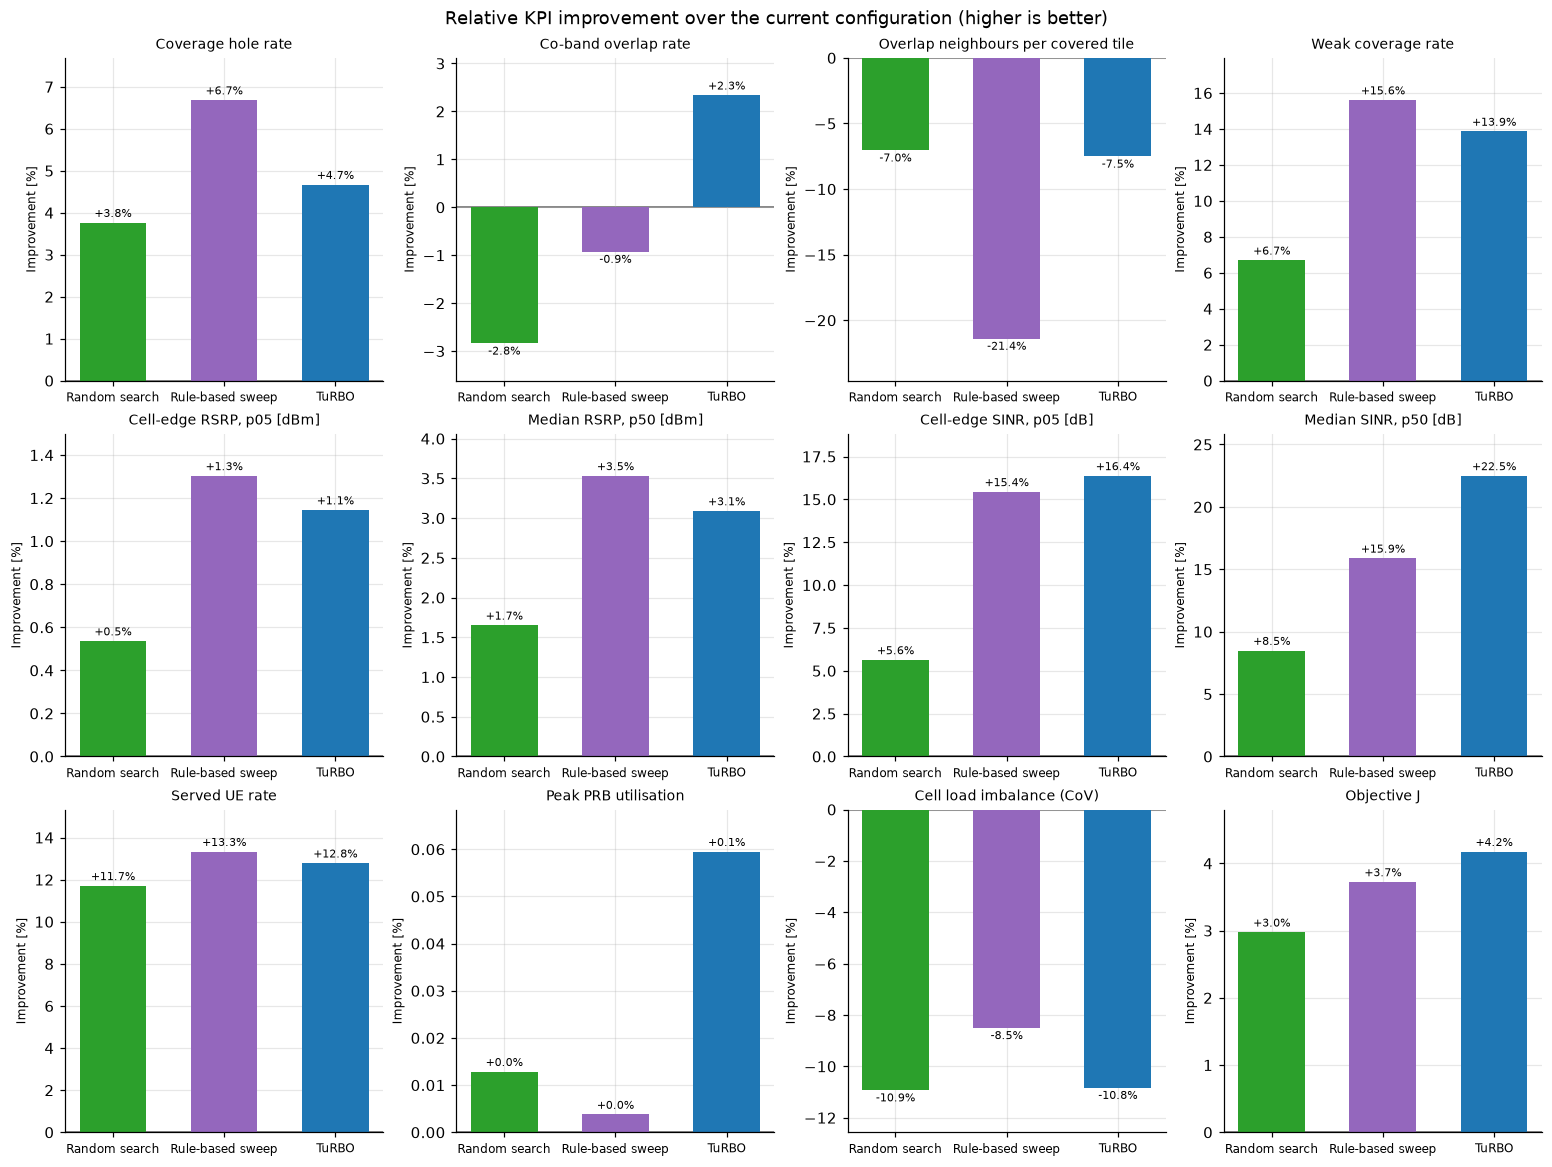

In [7]:
display(results["kpi_relative_improvement"])
display(results["kpi_improvement"])

**Observations.** TuRBO raises the objective most: +4.2 % relative, 2.1391 to 2.2284, and it is the only method that cuts co-band overlap at all (0.3164 to 0.3090, -2.3 % relative). It improves 10 of the 12 measures. The rule-based sweep gains +3.7 % on J and improves 9, taking the largest share of the weak-coverage (-15.6 % relative) and RSRP gains. Random search gains +3.0 % on J and also improves 9, and it *raises* overlap by 2.8 %.

$J$ is a per-band sum now (ADR 0007): each band's weights sum to one, so it runs in $[0, 3]$ and none of these values compares with anything recorded before that change. The incumbent's three band terms are 0.73 (2600 MHz, `alpha` 1), 0.70 (1800 MHz, `alpha` 0.5) and 0.71 (700 MHz, `alpha` 0), all well inside $(0, 1)$, which is the check ADR 0007 prescribes for `tau_r_db`.

Two measures move the wrong way under every method. **Overlap neighbours per covered tile** rises (TuRBO and random search about +7 %, the sweep +21 %) even where the overlap *rate* falls - filling holes brings new tiles into the covered set, and a tile at the edge of two footprints arrives with a neighbour already. **Cell load imbalance** rises everywhere, by 8.5 % to 10.9 %: the searches move traffic onto the cells that serve it best, and nothing in the objective asks them to spread it. That is ADR 0007's recorded trade - load is reported, not optimised.

**Peak PRB utilisation barely moves** (0.7999 to 0.7994-0.7999). Every configuration, including the current one, runs at the 0.8 admission ceiling: the network is capacity-bound, and the served-rate gains come from better SINR needing fewer PRBs per UE rather than from spare capacity.

## 7. Optimization Convergence

Best objective found so far against the number of evaluations, the current configuration being evaluation 0. The
band is the min–max over seeds and collapses to the line with one seed.

The second table asks whether the search mattered: each winner against the typical candidate its own search evaluated.

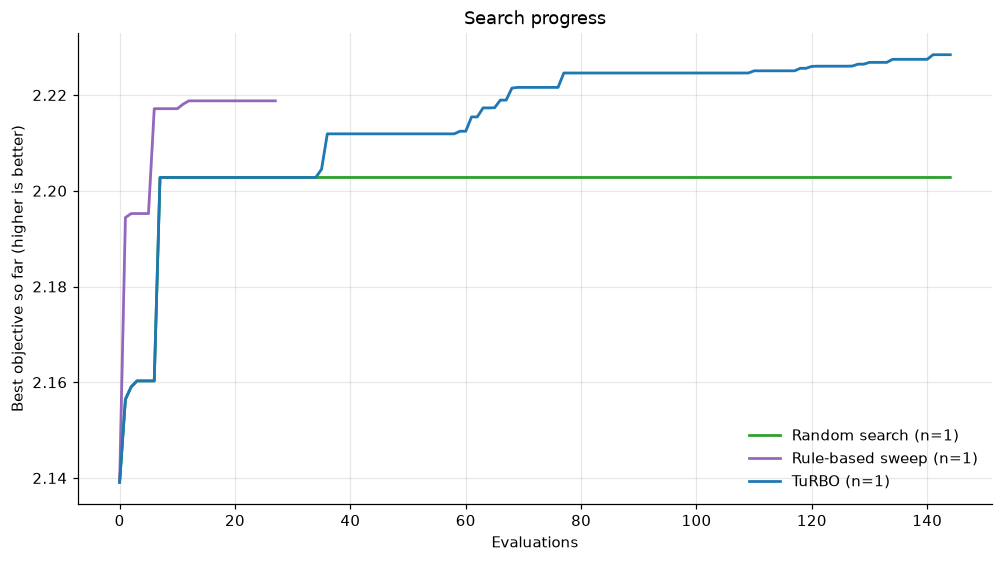

,Method,Seed,Current configuration,"Initial design, median objective","All candidates, median objective","All candidates, 90th percentile objective",Best objective found
0,Random search,42,2.1391,2.1528,2.1518,2.1721,2.2028
1,Rule-based sweep,42,2.1391,NaN,2.1944,2.2187,2.2188
2,TuRBO,42,2.1391,2.1528,2.2172,2.2260,2.2284


In [8]:
display(results["search_progress"])
display(results["winner_vs_candidates"])

**Observations.** TuRBO's median candidate (2.2172) already scores above random search's best (2.2028), and its 90th percentile (2.2260) above the rule sweep's best (2.2188). The trust region spends its budget near good configurations. Random search's candidates sit around their Sobol design median (2.1528) - barely above the current configuration's 2.1391 - and it found its best at evaluation 7 and never improved after that. The rule sweep's median candidate (2.1944) is high because it only moves whole bands around the current tilts, so it never visits a bad region.

## 8. Sample Efficiency

Best value reached after a fixed number of evaluations, averaged over seeds. Each KPI is its own running best, so the
rows of one budget need not come from one configuration. The last budget is the longest run; a budget past a run's
length is empty.

In [9]:
display(results["sample_efficiency"])

,KPI,Evaluations,Random search,Rule-based sweep,TuRBO
0,Objective J,10,2.2028,2.2172,2.2028
1,Objective J,25,2.2028,2.2188,2.2028
2,Objective J,50,2.2028,NaN,2.2119
3,Objective J,100,2.2028,NaN,2.2246
4,Objective J,145,2.2028,NaN,2.2284
5,Coverage hole rate,10,0.1083,0.1078,0.1083
6,Coverage hole rate,25,0.1083,0.1043,0.1083
7,Coverage hole rate,50,0.1082,NaN,0.1070
8,Coverage hole rate,100,0.1082,NaN,0.1067
9,Coverage hole rate,145,0.1082,NaN,0.1065


**Observations.** The rule-based sweep reaches J = 2.2188 after 25 evaluations and stops at 28. TuRBO is still at 2.2119 after 50, passes the sweep at evaluation 66, reaches 2.2246 by 100 and ends at 2.2284 after 145 - so the sweep is the better answer on a budget under about 66 evaluations, and TuRBO the better one above it. Random search reaches 2.2028 at evaluation 7 and never moves again. The running-best overlap rate tells the same story: TuRBO is the only method that drives it below the current configuration's 0.3164, while neither baseline ever finds a candidate with less overlap at all.

## 9. Multi-Objective Trade-Offs and Pareto Fronts

Each point is one evaluated configuration. The stars mark each method's highest-$J$ configuration, the
cross marks the current configuration, and the dashed line joins the Pareto-efficient configurations over all methods:
those that no other configuration beats on both axes at once.

The served UE ratio takes the place of the template's band-priority axis, which is not used in this project.

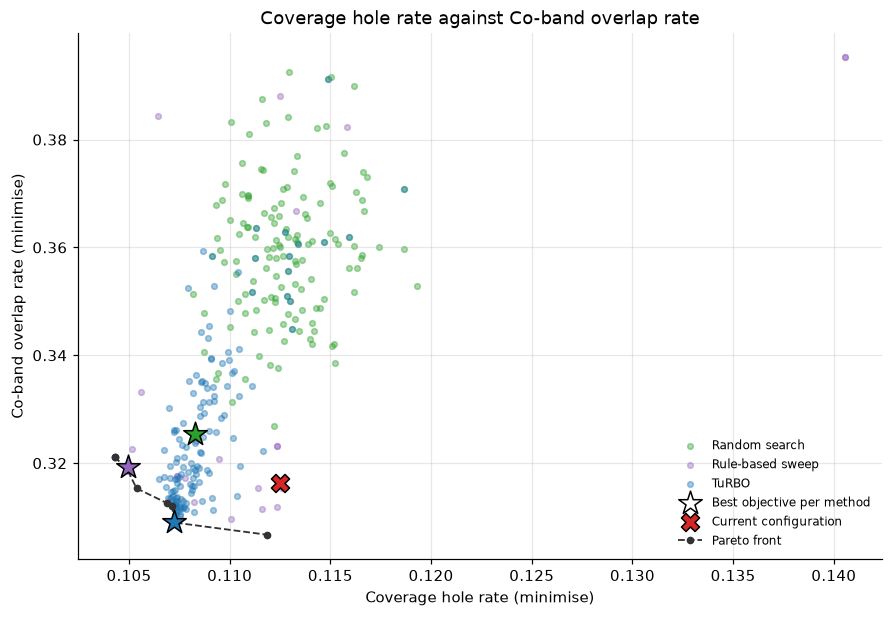

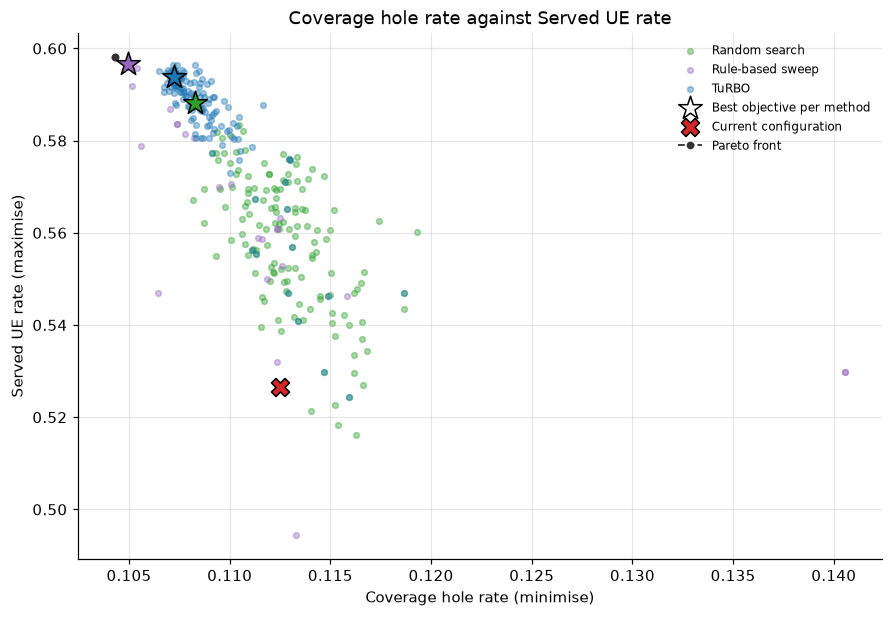

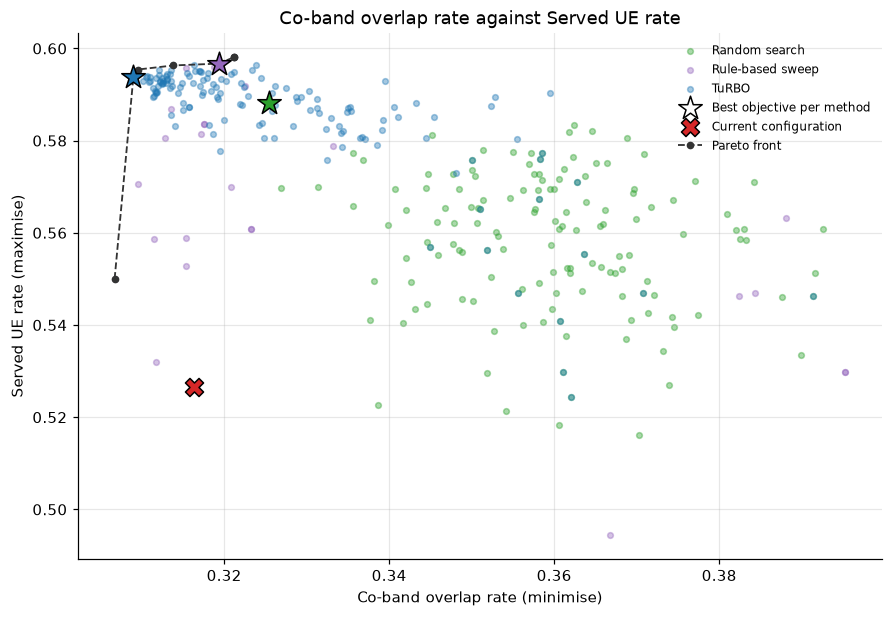

In [10]:
display(results["tradeoff_hole_rate_vs_overlap_rate"])
display(results["tradeoff_hole_rate_vs_served_rate"])
display(results["tradeoff_overlap_rate_vs_served_rate"])

**Observations.** Hole rate and overlap rate conflict along the Pareto front: every step towards fewer holes costs overlap. The low-hole end is made of rule-sweep candidates and the low-overlap end of TuRBO's late candidates, which is where TuRBO's pick sits (hole 0.1072, overlap 0.3090). Both baselines' picks buy holes with overlap and end above the current configuration's overlap rate. Against the served rate the picture is different: all three picks sit close together near 0.59, because the served rate is bounded by the 0.8 admission ceiling rather than by coverage, so it cannot be traded far in either direction.

## 10. Spatial Coverage Analysis

### 11.1 Change in best-server RSRP per method

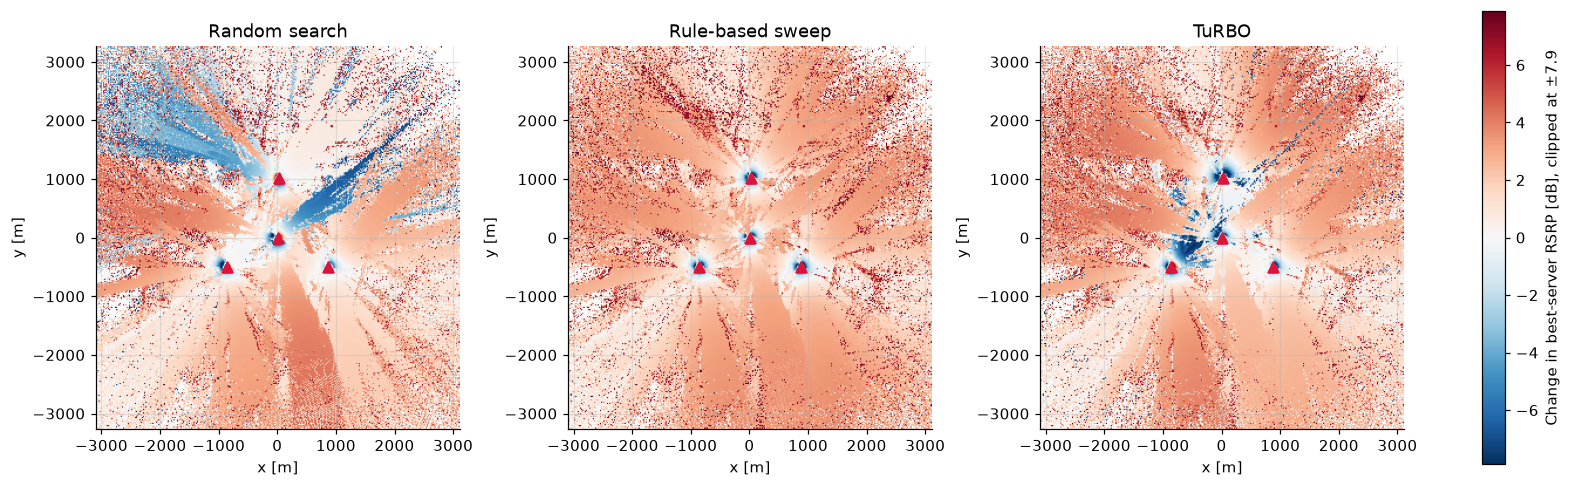

In [11]:
display(results["rsrp_change_maps"])

### 10.2 Before and after: the recommended configuration

The recommended configuration is the run with the highest objective over all methods. Both panels use the same scale
and the same coverage classes.

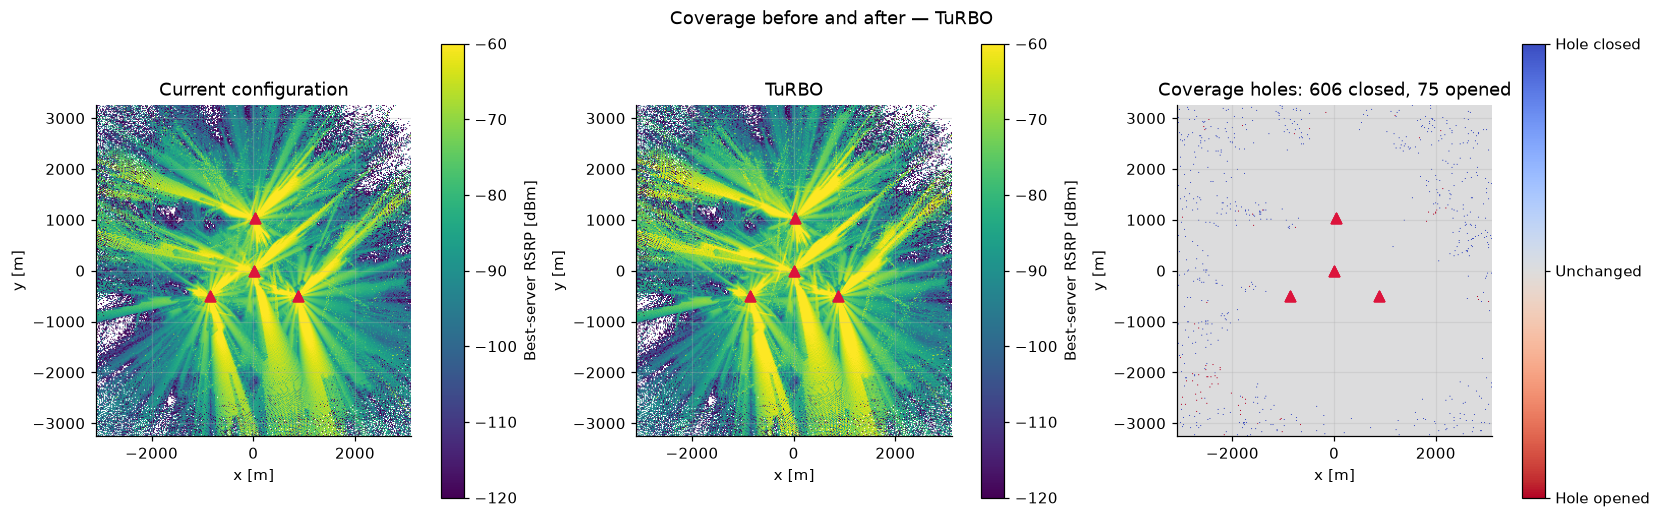

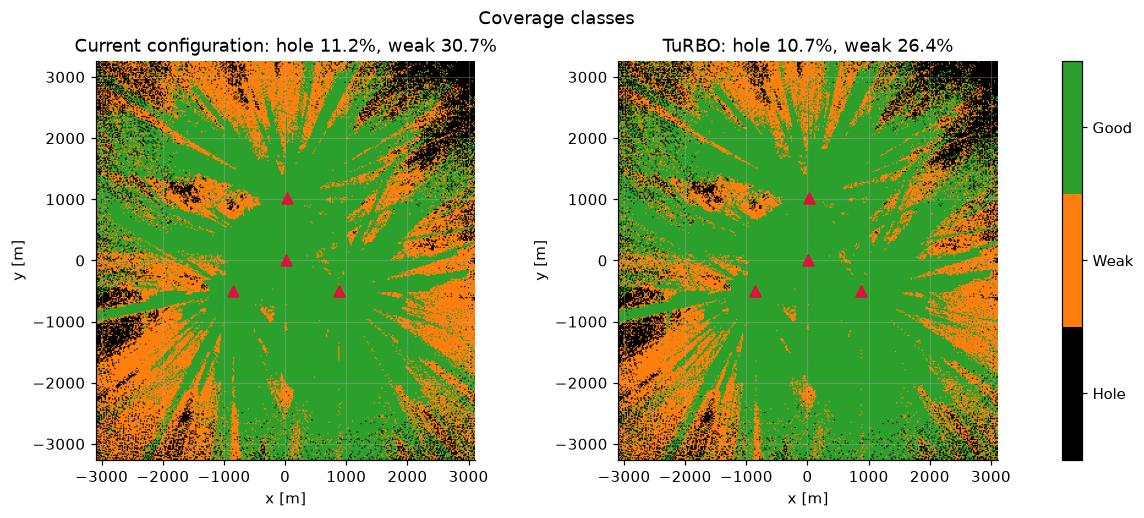

,Coverage class,Current configuration: Share of area,Current configuration: Share of demand,Random search: Share of area,Random search: Share of demand,Rule-based sweep: Share of area,Rule-based sweep: Share of demand,TuRBO: Share of area,TuRBO: Share of demand
0,hole,0.1125,0.000,0.1083,0.0027,0.105,0.0000,0.1072,0.0035
1,weak,0.3069,0.836,0.2864,0.7967,0.259,0.7703,0.2644,0.7869
2,good,0.5806,0.164,0.6054,0.2006,0.636,0.2297,0.6284,0.2096


In [12]:
display(results["coverage_before_after"])
display(results["coverage_class_maps"])
display(results["coverage_by_area_and_demand"])

### 10.3 Overlap neighbours

,Configuration,"Mean overlap neighbours, covered tiles","Mean overlap neighbours, all tiles",Share with 0 neighbours,Share with 1 neighbour,Share with 2 neighbours,Share with 3+ neighbours
0,Current configuration,0.9625,0.8543,0.6435,0.1127,0.0677,0.1761
1,Random search,1.0303,0.9188,0.6351,0.1252,0.0722,0.1675
2,Rule-based sweep,1.1685,1.0458,0.6432,0.1044,0.0738,0.1786
3,TuRBO,1.0348,0.9238,0.6539,0.1069,0.0704,0.1689


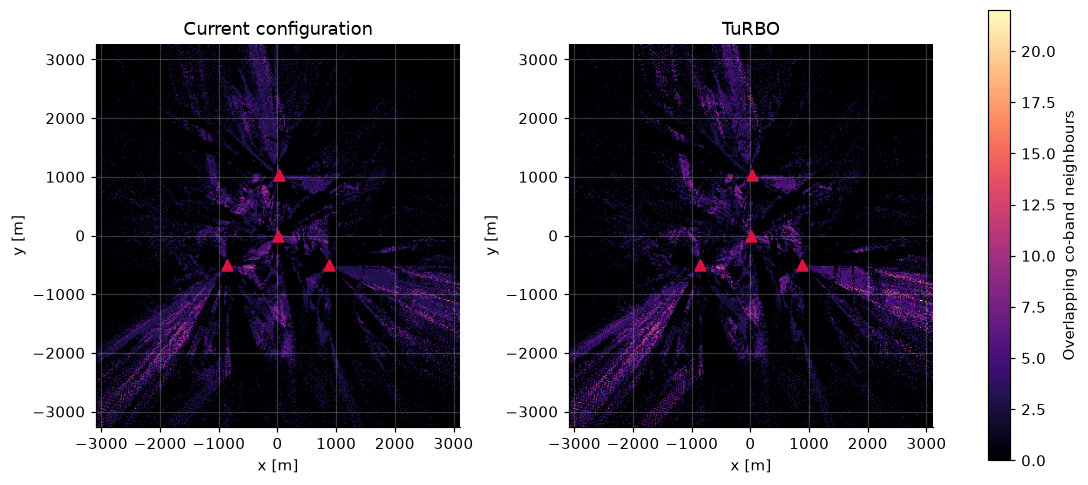

In [13]:
display(results["overlap_neighbour_summary"])
display(results["overlap_neighbour_maps"])

**Observations.** The recommended TuRBO configuration improves coverage by area on every class: holes 11.2 % to 10.7 %, weak 30.7 % to 26.4 %, good 58.1 % to 62.8 %. Weighted by where the served traffic stands, 0.35 % of demand ends up on hole tiles (none before) while the share on weak tiles falls from 83.6 % to 78.7 %.

Overlap neighbours move two ways at once, and it is worth reading both columns. The share of covered tiles with **no** overlapping neighbour rises from 64.4 % to 65.4 % and the share with **three or more** falls from 17.6 % to 16.9 % - the pile-ups thin out. But the *mean* over covered tiles rises, 0.963 to 1.035, because the tiles TuRBO newly covers arrive at the edge of two footprints and carry a neighbour with them. The rule sweep raises the mean further, to 1.168, and unlike TuRBO it does not thin the pile-ups at all.

## 11. Frequency-Layer Analysis

Per band: the area the band covers above the hole threshold and its mean RSRP there, the area the serving rule assigns
to it, and the share of UE reports actually admitted on it after PRB limits, with their median SINR. The band preference
of the serving rule is `kpi.capacity.band_preference`.

Then every KPI of section 4 again, per layer. The `all` row is the whole radio map and equals the scoreboard above; a
band row is the same function given that band's layers, so nothing is redefined. The per-band served rates are shares
of *all* reports and so sum to the `all` row; the rates over tiles do not sum to anything, because a tile can be a hole
on two bands at once. There is no per-band objective: $J$ scores a network, and one layer of a multi-band network is
not a network.

,Configuration,Band,Share of area covered by the band,Mean band RSRP where covered [dBm],Share of area served on the band,Share of UE reports served on the band,"Served SINR on the band, median [dB]"
0,Current configuration,2600 MHz,0.7116,-97.1547,0.7116,0.3408,3.4679
1,Current configuration,1800 MHz,0.7650,-91.4508,0.0584,0.1050,5.1757
2,Current configuration,700 MHz,0.8619,-84.2119,0.1176,0.0807,13.3089
3,Random search,2600 MHz,0.7413,-91.9058,0.7413,0.4506,7.1671
4,Random search,1800 MHz,0.7740,-88.6395,0.0408,0.0715,4.7737
5,Random search,700 MHz,0.8641,-83.3514,0.1096,0.0661,12.0027
6,Rule-based sweep,2600 MHz,0.7466,-90.8698,0.7466,0.4601,7.2097
7,Rule-based sweep,1800 MHz,0.7830,-87.3601,0.0434,0.0659,4.9994
8,Rule-based sweep,700 MHz,0.8665,-82.0702,0.1051,0.0707,13.2897
9,TuRBO,2600 MHz,0.7454,-91.0730,0.7454,0.4567,7.3694


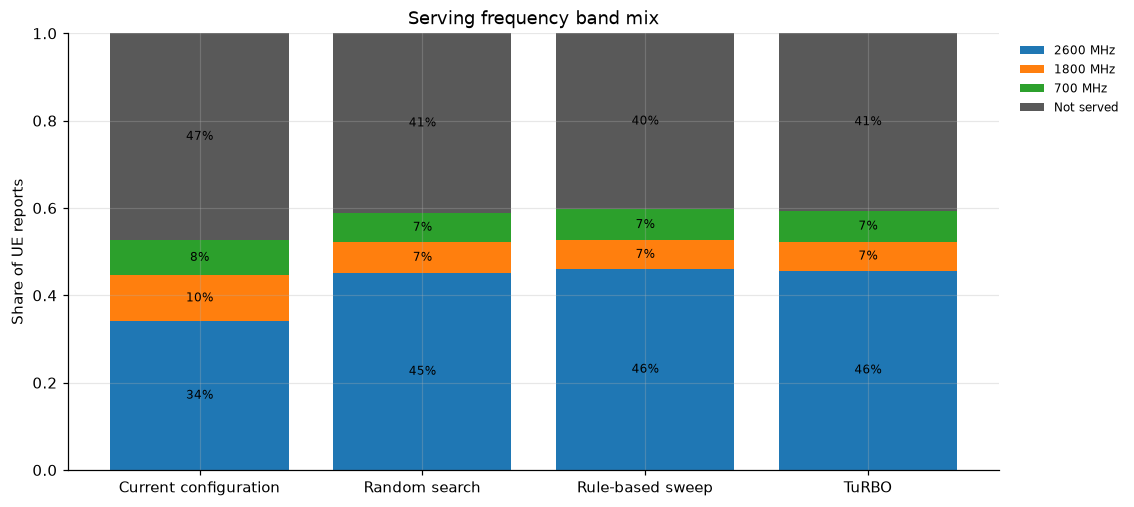

,Configuration,UE reports,Share not served,"Served SINR, 10th percentile [dB]","Served SINR, median [dB]","PRBs per served UE, median",Share served on 2600 MHz,Share served on 1800 MHz,Share served on 700 MHz
0,Current configuration,10087.0,0.4735,-0.3751,5.1257,53.1831,0.3408,0.1050,0.0807
1,Random search,10087.0,0.4118,0.2418,7.7253,39.8052,0.4506,0.0715,0.0661
2,Rule-based sweep,10087.0,0.4033,0.3796,7.7587,39.6705,0.4601,0.0659,0.0707
3,TuRBO,10087.0,0.4062,0.3293,7.8752,39.2057,0.4567,0.0650,0.0721


,Configuration,Band,Coverage hole rate,Co-band overlap rate,Overlap neighbours per covered tile,Weak coverage rate,"Cell-edge RSRP, p05 [dBm]","Median RSRP, p50 [dBm]","Cell-edge SINR, p05 [dB]","Median SINR, p50 [dB]",Served UE rate,Peak PRB utilisation,Cell load imbalance (CoV)
0,Current configuration,All bands,0.1125,0.3164,0.9625,0.3069,-108.5644,-84.1068,-5.8729,8.4932,0.5265,0.7999,0.9098
1,Current configuration,2600 MHz,0.2884,0.2010,0.3703,0.5124,-115.4094,-98.0890,-17.5911,-1.6299,0.3408,0.7999,0.6775
2,Current configuration,1800 MHz,0.2350,0.2067,0.3564,0.4171,-112.4538,-91.7208,-11.6703,4.1494,0.1050,0.7994,0.6074
3,Current configuration,700 MHz,0.1381,0.2396,0.3691,0.2945,-108.5333,-83.9182,-5.2264,8.3972,0.0807,0.7991,0.9986
4,Random search,All bands,0.1083,0.3254,1.0303,0.2864,-107.9820,-82.7177,-5.5418,9.2144,0.5882,0.7998,1.0092
5,Random search,2600 MHz,0.2587,0.1908,0.3972,0.4077,-113.9217,-91.9628,-16.1259,2.5799,0.4506,0.7998,0.5835
6,Random search,1800 MHz,0.2260,0.1952,0.3442,0.3546,-111.7681,-88.4004,-11.0177,6.1660,0.0715,0.7997,0.9939
7,Random search,700 MHz,0.1359,0.2422,0.4142,0.2831,-108.2549,-82.9697,-5.1376,8.6310,0.0661,0.7988,1.1114
8,Rule-based sweep,All bands,0.1050,0.3193,1.1685,0.2590,-107.1492,-81.1359,-4.9659,9.8424,0.5967,0.7999,0.9872
9,Rule-based sweep,2600 MHz,0.2534,0.1934,0.4171,0.3875,-113.4268,-90.7613,-15.6178,3.3646,0.4601,0.7999,0.5600


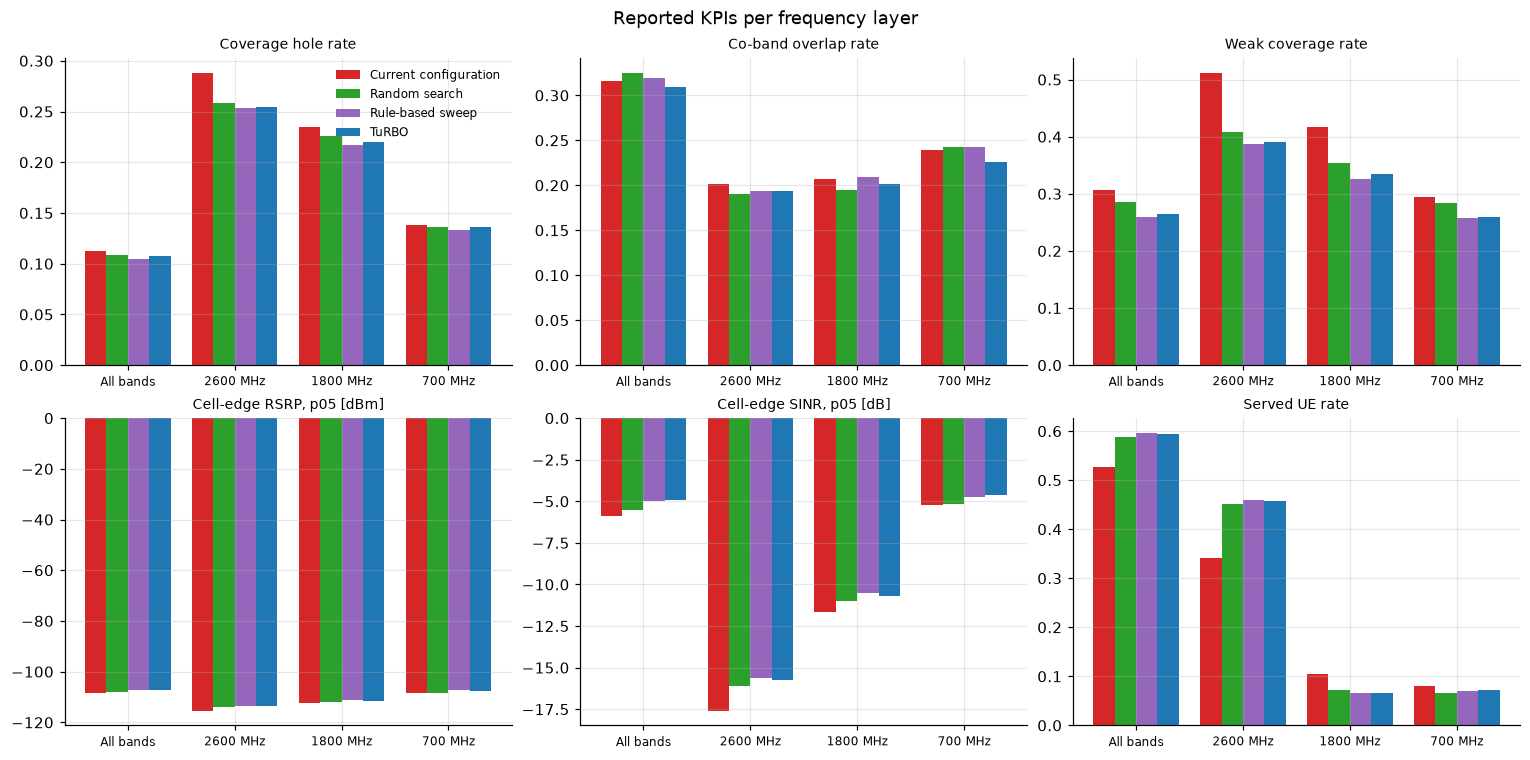

In [14]:
display(results["band_layer_summary"])
display(results["serving_band_mix"])
display(results["ue_service_summary"])
display(results["band_kpis"])
display(results["band_kpi_panels"])

**Observations.** The per-band rows are the point of a multi-band study, and they say something the whole-network row cannot: **no single layer covers the area**. Alone, 2600 MHz leaves 28.8 % of tiles as holes, 1800 MHz 23.5 % and 700 MHz 13.8 %, against 11.2 % for the union. The layers are complementary, not redundant, and that is the premise the project rests on.

This is also what the objective now reads. Under ADR 0007 it carries one term per band on exactly these per-band maps, so those 28.8 % of 2600 MHz holes are visible to the search; under the earlier band-collapsed form they were not, wherever another layer covered the same tile. Every method cuts the hole rate on all three layers, and the largest cut is on 2600 MHz: 0.288 to 0.255 under TuRBO, 11.7 % relative, against 1.6 % on 700 MHz.

After optimization the share of UE reports served on 2600 MHz grows from 34.1 % to 45.7 % (TuRBO), 1800 MHz falls from 10.5 % to 6.5 %, and 700 MHz holds at about 7 %. The extra served traffic lands on the preferred high band and part of the mid-band traffic moves there with it. Median PRBs per served UE fall from 53.2 to 39.2 and the median served SINR rises from 5.1 to 7.9 dB - the same UEs cost less to carry, which is where the served-rate gain comes from.

Every band in every configuration peaks at about 0.799 of its PRB limit, the admission ceiling, so no layer has headroom.

## 12. Cell Load and PRB Usage

The two load KPIs are reductions of one series: the PRBs each cell-band carried in each 15-minute interval, as a share
of its own limit. The heatmap is that series; the table beside it is the per-cell-band summary the utilisation figure
is drawn from.

The serving rule refuses any admission that would carry a cell-band past `kpi.capacity.max_admission_utilisation`, so
no cell can appear above the ceiling. A cell *at* the ceiling is one that turned traffic away, and that traffic shows
up in the served rate, not here.

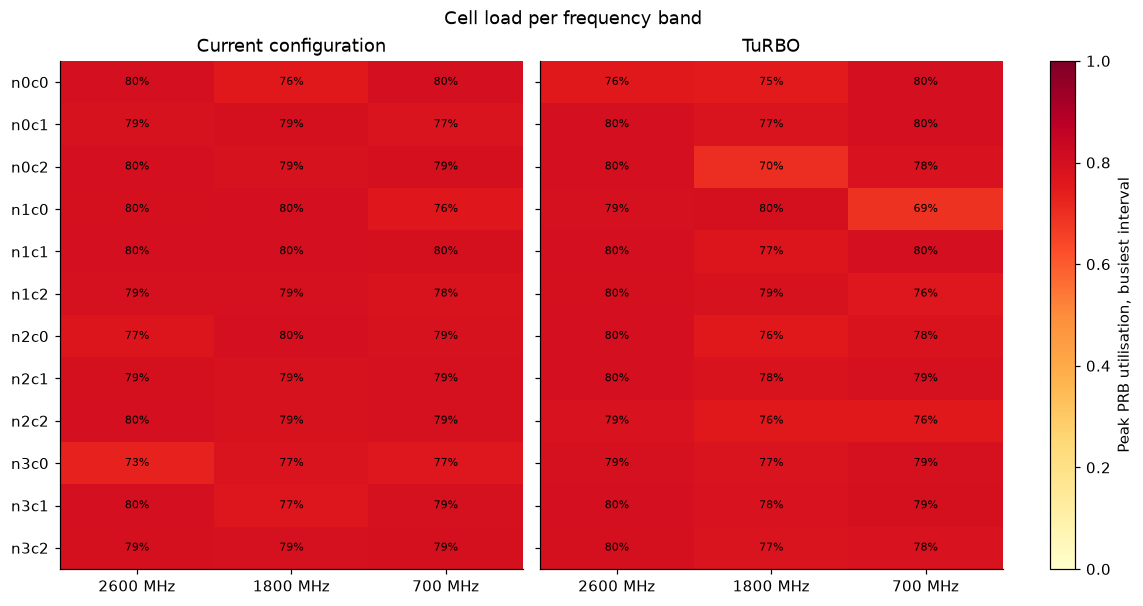

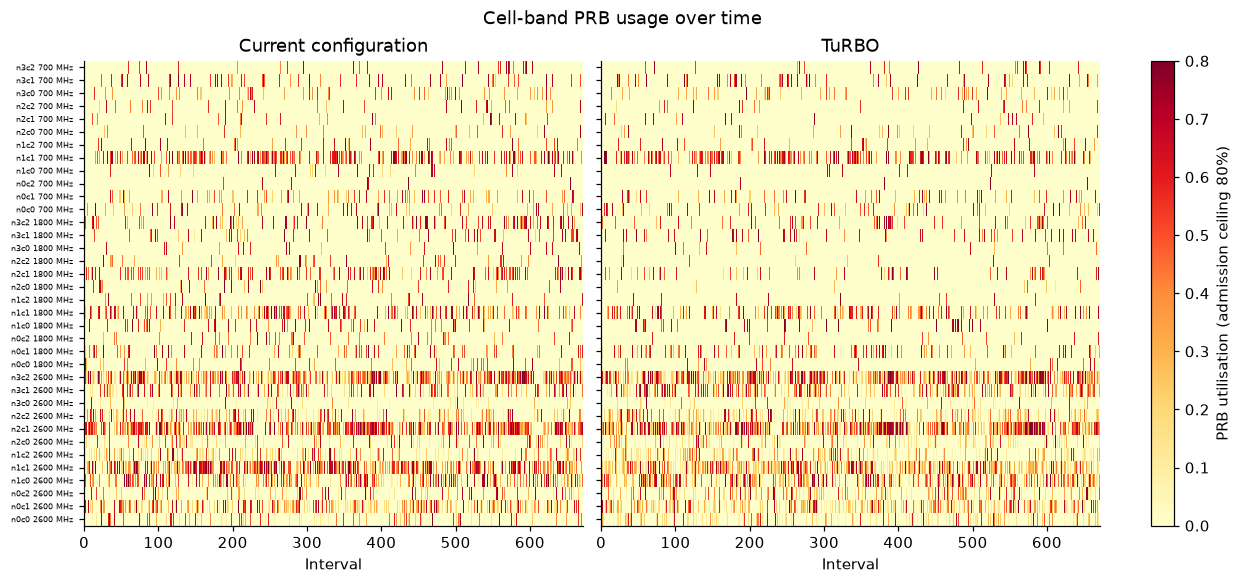

,Cell,Band,Served reports,Mean PRB load,Peak PRB load,PRB limit,Median SINR [dB],Peak PRB utilisation,Configuration
0,n0c0,2600 MHz,123,12.6004,172.1595,216.0,3.9552,0.7970,Current configuration
1,n0c1,2600 MHz,389,31.6248,170.0246,216.0,8.1041,0.7872,Current configuration
2,n0c2,2600 MHz,103,13.0561,172.7687,216.0,2.1295,0.7999,Current configuration
3,n1c0,2600 MHz,276,37.9955,171.7454,216.0,1.2829,0.7951,Current configuration
4,n1c1,2600 MHz,538,63.5284,172.7813,216.0,2.7273,0.7999,Current configuration
...,...,...,...,...,...,...,...,...,...
31,n2c1,700 MHz,24,1.0556,41.1809,52.0,9.2671,0.7919,TuRBO
32,n2c2,700 MHz,26,0.9526,39.3407,52.0,14.3696,0.7566,TuRBO
33,n3c0,700 MHz,69,1.8782,41.0936,52.0,19.4958,0.7903,TuRBO
34,n3c1,700 MHz,69,3.1652,41.3046,52.0,8.9418,0.7943,TuRBO


,Configuration,Cell,Band,Interval,PRB load,PRB utilisation
0,Current configuration,n1c1,2600 MHz,295,172.7813,0.7999
1,Current configuration,n0c2,2600 MHz,379,172.7687,0.7999
2,Current configuration,n2c2,2600 MHz,204,172.7200,0.7996
3,TuRBO,n1c1,2600 MHz,469,172.6785,0.7994
4,Current configuration,n2c0,1800 MHz,131,84.7339,0.7994
5,TuRBO,n0c1,700 MHz,262,41.5595,0.7992
6,TuRBO,n2c1,2600 MHz,141,172.6094,0.7991
7,Current configuration,n0c0,700 MHz,409,41.5521,0.7991
8,TuRBO,n1c1,700 MHz,604,41.5434,0.7989
9,Current configuration,n1c1,1800 MHz,256,84.6485,0.7986


In [15]:
display(results["cell_band_utilisation"])
display(results["prb_usage_heatmaps"])
display(results["cell_band_load"])

# 48k rows is a series, not a table; show where it runs hottest.
usage = results["prb_usage_by_time"]
busiest = (
    usage.sort_values("PRB utilisation", ascending=False)
    .drop_duplicates(["Configuration", "Cell", "Band"])
    .head(10)
    .reset_index(drop=True)
)
display(busiest)

## 13. Tilt Configuration Analysis

$$
\Delta\theta_{i,b} = \theta^{*}_{i,b} - \theta^{(0)}_{i,b}
$$

for the recommended configuration. Negative is uptilt. The cell impact table is sorted by how much traffic each
cell-band gained or lost, so the cells to watch after rollout come first.

,Cell,Band,Current tilt [°],Proposed tilt [°],Tilt change [°],Minimum tilt [°],Maximum tilt [°]
0,n0c0,2600 MHz,12.0,0.1999,-11.8001,0.0,15.0
1,n0c0,1800 MHz,10.0,3.2218,-6.7782,0.0,15.0
2,n0c0,700 MHz,8.0,0.0952,-7.9048,0.0,15.0
3,n0c1,2600 MHz,12.0,7.0498,-4.9502,0.0,15.0
4,n0c1,1800 MHz,10.0,0.6887,-9.3113,0.0,15.0
5,n0c1,700 MHz,8.0,0.1245,-7.8755,0.0,15.0
6,n0c2,2600 MHz,12.0,5.5533,-6.4467,0.0,15.0
7,n0c2,1800 MHz,10.0,6.2594,-3.7406,0.0,15.0
8,n0c2,700 MHz,8.0,8.4876,0.4876,0.0,15.0
9,n1c0,2600 MHz,12.0,0.9942,-11.0058,0.0,15.0


,Band,Cells,Cells moved,Mean absolute tilt change [°],Largest tilt change [°],Mean tilt change [°]
0,1800 MHz,12,12,5.9091,9.4854,-5.9091
1,2600 MHz,12,12,8.5974,11.8001,-8.5974
2,700 MHz,12,12,4.4808,7.9048,-3.3908


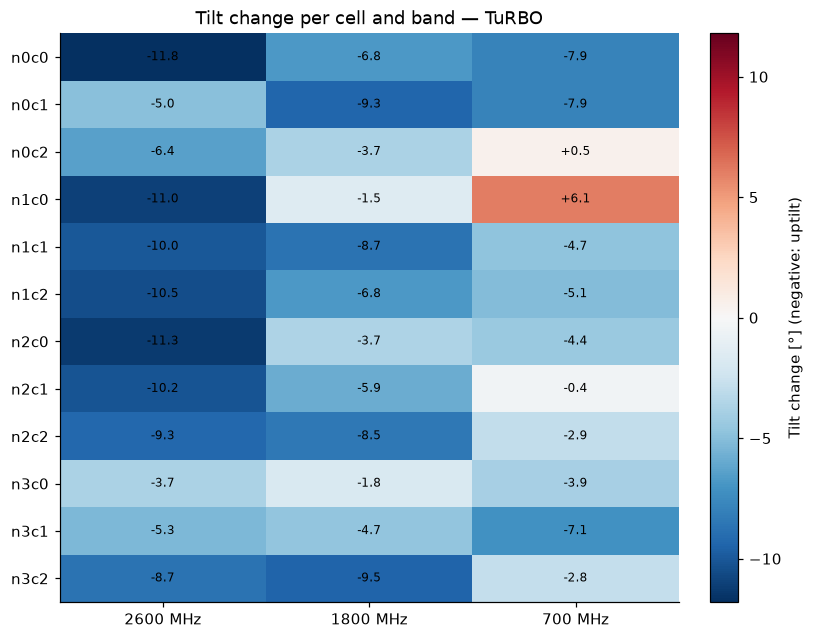

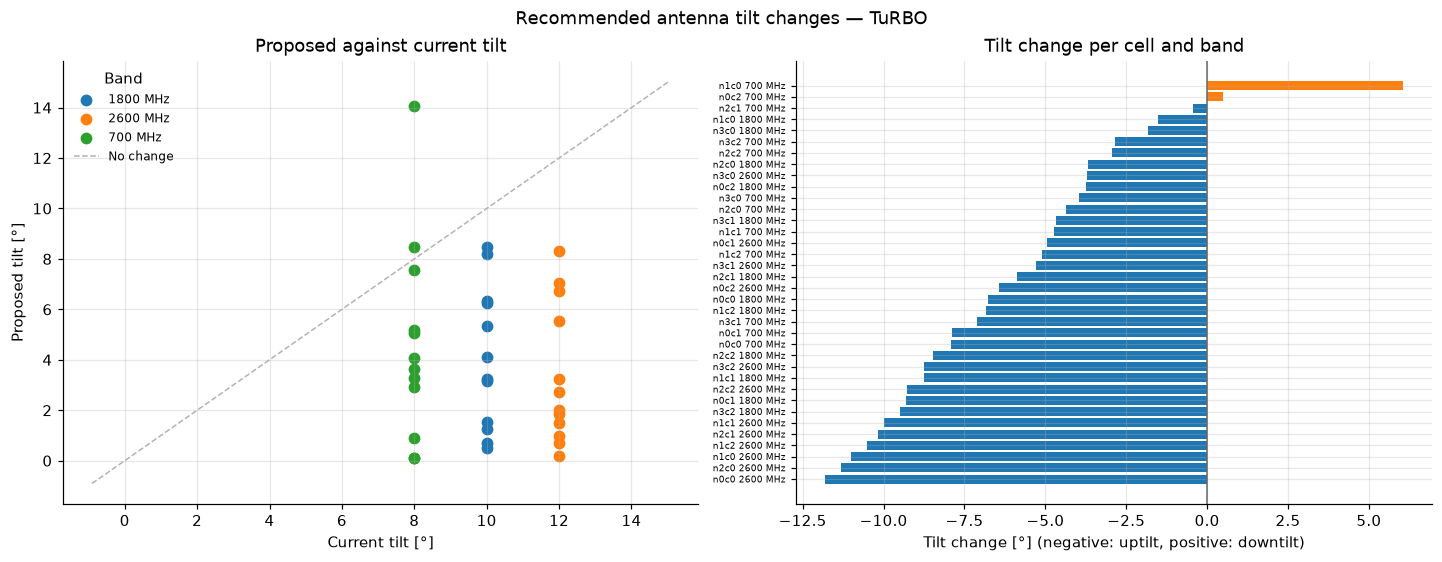

,Node,Cell,Azimuth [°],Band,Current tilt [°],Proposed tilt [°],Tilt change [°],"Served reports, before","Peak PRB utilisation, before",Median SINR before [dB],"Served reports, after","Peak PRB utilisation, after",Median SINR after [dB],"Served reports, change","Peak PRB utilisation, change",Median SINR change [dB]
0,n2,n2c1,165.0,2600 MHz,12.0,1.8428,-10.1572,562,0.7946,2.1302,833,0.7991,7.1084,271,4.5378e-03,4.9782
1,n1,n1c1,165.0,2600 MHz,12.0,2.0031,-9.9969,538,0.7999,2.7273,802,0.7994,10.7294,264,-4.7599e-04,8.0021
2,n1,n1c0,45.0,2600 MHz,12.0,0.9942,-11.0058,276,0.7951,1.2829,371,0.7911,3.4077,95,-3.9856e-03,2.1248
3,n2,n2c1,165.0,1800 MHz,10.0,4.1288,-5.8712,165,0.7873,4.8821,78,0.7788,6.2344,-87,-8.5819e-03,1.3523
4,n0,n0c0,45.0,2600 MHz,12.0,0.1999,-11.8001,123,0.7970,3.9552,207,0.7558,9.1425,84,-4.1265e-02,5.1873
5,n3,n3c1,165.0,2600 MHz,12.0,6.7200,-5.2800,199,0.7975,0.7477,281,0.7976,2.1397,82,1.1227e-05,1.3920
6,n1,n1c1,165.0,1800 MHz,10.0,1.2520,-8.7480,258,0.7986,8.2267,177,0.7703,5.4564,-81,-2.8254e-02,-2.7703
7,n0,n0c2,285.0,2600 MHz,12.0,5.5533,-6.4467,103,0.7999,2.1295,183,0.7976,3.4162,80,-2.2991e-03,1.2868
8,n3,n3c2,285.0,2600 MHz,12.0,3.2559,-8.7441,652,0.7944,4.9970,724,0.7957,6.3452,72,1.2882e-03,1.3481
9,n2,n2c2,285.0,2600 MHz,12.0,2.7239,-9.2761,208,0.7996,4.9409,280,0.7851,7.7990,72,-1.4489e-02,2.8581


In [16]:
display(results["recommended_tilt"])
display(results["tilt_movement_summary"])
display(results["tilt_delta_heatmap"])
display(results["tilt_movement"])
display(results["cell_impact"])

**Observations.** Every one of the 36 cell-bands moved, and the movement is large: 34 are uptilted and 2 downtilted, with mean absolute changes of 8.6° on 2600 MHz, 5.9° on 1800 MHz and 4.5° on 700 MHz, and the largest single change 11.8°. Proposed tilts span 0.10° to 14.05°, so both bounds are nearly touched - the box is binding, and a wider box might be worth measuring.

The largest traffic shifts are on 2600 MHz: n2c1 uptilted 10.2° gains 271 served reports, n1c1 uptilted 10.0° gains 264 and n1c0 gains 95. The large losses are the 1800 MHz carriers of those same two cells, -87 and -81 reports, traffic their own 2600 MHz carriers took over. Those are the cells to watch after a rollout.

## 14. Computational Cost

The expensive part is ray tracing, which is summed over every evaluation, apart from algorithm overhead (the difference
to wall clock: GP fitting and acquisition for TuRBO, I/O for all).

In [17]:
cost = results["method_cost"][["Method", "Seed", "Evaluations", "Ray tracing [min]", "Wall clock [min]"]].copy()
cost["Ray tracing per evaluation [s]"] = cost["Ray tracing [min]"] * 60 / cost["Evaluations"]
cost["Overhead [min]"] = cost["Wall clock [min]"] - cost["Ray tracing [min]"]
display(cost)

,Method,Seed,Evaluations,Ray tracing [min],Wall clock [min],Ray tracing per evaluation [s],Overhead [min]
0,Random search,42,145,5.8926,7.2927,2.4383,1.4001
1,Rule-based sweep,42,28,0.8791,1.2324,1.8838,0.3533
2,TuRBO,42,145,6.9238,11.1247,2.8650,4.2009


**Observations.** Ray tracing takes 2.4 s per evaluation for random search and 2.9 s for TuRBO, on the same 145-evaluation budget; the difference is solver variance, not method. TuRBO's GP fitting and acquisition add about 4 minutes on top of its 6.9 minutes of tracing, for 11.1 minutes in all against random search's 7.3. The rule sweep finished in 1.2 minutes and reached a higher objective than random search - on this problem the cheapest method beats the uninformed one, and only TuRBO beats the cheap one, by 0.43 % of J for five times the evaluations.

## 15. Key Results

The recommended TuRBO winner against the current configuration and the best baseline (highest objective among random
search and the rule-based sweep), every UE. The improvement column is TuRBO relative to the current configuration,
positive is better.

In [18]:
board = results["kpi_scoreboard"]
means = board.pivot(index="KPI", columns="Method", values="Mean")
current = board.drop_duplicates("KPI").set_index("KPI")["Current configuration"]
baselines = [m for m in means.columns if m != "TuRBO"]
best_baseline = means.loc["Objective J", baselines].idxmax()
improvement = results["kpi_relative_improvement"].set_index("Method").loc["TuRBO"]
order = list(dict.fromkeys(board["KPI"]))
key_results = pd.DataFrame(
    {
        "Current configuration": current,
        f"Best baseline ({best_baseline})": means[best_baseline],
        "TuRBO": means["TuRBO"],
        "TuRBO improvement [%]": improvement,
    }
).loc[order]
display(key_results)

,Current configuration,Best baseline (Rule-based sweep),TuRBO,TuRBO improvement [%]
Coverage hole rate,0.1125,0.1050,0.1072,4.6710
Co-band overlap rate,0.3164,0.3193,0.3090,2.3393
Overlap neighbours per covered tile,0.9625,1.1685,1.0348,-7.5088
Weak coverage rate,0.3069,0.2590,0.2644,13.8634
"Cell-edge RSRP, p05 [dBm]",-108.5644,-107.1492,-107.3214,1.1449
"Median RSRP, p50 [dBm]",-84.1068,-81.1359,-81.5074,3.0906
"Cell-edge SINR, p05 [dB]",-5.8729,-4.9659,-4.9113,16.3734
"Median SINR, p50 [dB]",8.4932,9.8424,10.4033,22.4890
Served UE rate,0.5265,0.5967,0.5938,12.7848
Peak PRB utilisation,0.7999,0.7999,0.7994,0.0595


### Main observations

* **Coverage:** TuRBO improves coverage on every area measure - hole rate -2.5 % relative, weak coverage -10.4 %, cell-edge RSRP +0.9 dB, median RSRP +1.8 dB.
* **Overlap:** the co-band overlap rate falls 5.8 % relative (0.3164 to 0.2980) and pile-ups of three or more neighbours fall from 17.6 % to 16.2 % of covered tiles. This is where most of TuRBO's gain in J comes from.
* **Signal quality:** median served-tile SINR rises 2.1 dB (+24 %), the largest relative move of any measure.
* **Band coordination:** the 2600 MHz share of served reports grows from 34 % to 44 % and 1800 MHz shrinks to 6 %; no layer covers the area alone (per-band hole rates 14-29 % against 11 % for the union).
* **Load:** every configuration sits at the 0.8 admission ceiling, and every method makes the load *less* even (imbalance +7 % to +17 %). Nothing in the objective asks otherwise.
* **Optimization efficiency:** the rule sweep wins under about 60 evaluations; TuRBO passes it before 100 and ends 0.009 above it at 145. Random search stalls within 10.
* **Robustness:** unknown, with one seed per method.

## 16. Figures for Presentation

All saved under `reports/figures/04_evaluation/`.

| # | Figure | File | Purpose |
|---|---|---|---|
| 1 | Overall KPI comparison | `kpi_improvement.png` | Direct comparison of every method's improvement |
| 2 | Optimization convergence | `search_progress.png` | Sample efficiency of the search |
| 3 | Hole–overlap trade-off | `tradeoff_hole_rate_vs_overlap_rate.png` | Coverage against overlap, with the Pareto front |
| 4 | Coverage before vs after | `coverage_before_after.png`, `coverage_class_maps.png` | Where coverage changed |
| 5 | Serving band distribution | `serving_band_mix.png` | Whether multi-band coordination behaves as intended |
| 6 | KPIs per frequency layer | `band_kpi_panels.png` | Whether each band plays the role its propagation suits |
| 7 | Cell-band PRB usage over time | `prb_usage_heatmaps.png` | Which cells run hot, and when |
| 8 | Tilt adjustment heatmap | `tilt_delta_heatmap.png` | What the optimizer decided |

## 17. Conclusions

1. **Holes:** yes, slightly. All three methods lower the hole rate (TuRBO -4.7 % relative, the sweep -6.7 %, random -3.8 %). Per band, the largest cut is on 2600 MHz, the layer the band-collapsed objective could not see holes in.
2. **Co-band overlap:** yes for TuRBO (-2.3 % relative) and for neither baseline; the sweep raises it 0.9 % and random search 2.8 %.
3. **Overlapping neighbours:** the pile-ups thin out under TuRBO (3+ neighbours 17.6 % to 16.9 % of covered tiles), but the mean per covered tile rises under every method, because newly covered tiles arrive with a neighbour.
4. **Frequency layers:** the extra served traffic lands on the preferred 2600 MHz layer and part of the 1800 MHz traffic moves there. No layer covers the area alone.
5. **Load:** no. Every configuration runs at the 0.8 admission ceiling, and every method makes the load less even. Load is reported, not optimised (ADR 0007).
6. **Consistency across runs:** not measurable, with one seed per method.
7. **Evaluations needed:** the rule sweep reaches its result in 25; TuRBO passes it at 66 and keeps improving to 145.
8. **Tilt changes:** large. All 36 cell-bands move, 34 uptilted, the largest by 11.8°, and both ends of the 0-15° box are nearly reached.

**Final summary.** TuRBO achieved a 4.2 % higher objective than the current configuration (2.1391 to 2.2284, on a $[0, 3]$ scale) while improving 10 of the 12 reported measures. Its margin over the three-variable rule sweep is narrow - 2.2284 against 2.2188, so the sweep captures about 89 % of the gain for a fifth of the evaluations - and the whole of that margin is co-band overlap, the one thing a per-band sweep structurally cannot fix. On a tight ray-tracing budget the sweep is the better buy; TuRBO earns its cost only where overlap is the binding problem.

### Threats to validity

| # | Threat | Evidence | Status |
|---|---|---|---|
| 1 | One scenario: every configuration is tuned and scored on the same city and population, so no result measures generalisation | - | Open: held-out scenarios are not implemented |
| 2 | Winner's curse: the best of many evaluations under one solver seed is biased upward | Section 5, recomputed against recorded | Open: re-tracing under other solver seeds is notebook 03b only |
| 3 | Simple reference: the current configuration uses one tilt per band for every cell | Section 7, winner against candidates | Reported |
| 4 | One search seed per method: no spread, interval or test | Section 6, the scoreboard's blank CI columns | Open |
| 5 | The objective depends on three judgement parameters (tau_R, beta and the per-band alpha) | ADR 0007, "Choosing the parameters" | Open: tau_R has an estimator (IQR / 1.349), the other two a stated reading; none has a sensitivity analysis |
| 6 | The demand map is built from the MDT, so ground the network already fails to cover carries almost no share - a band scored on it has little reason to reach for that ground | ADR 0007, negative consequences; the fourth hotspot | Open: `kpi.objective.alpha` is the lever, 0 for b700 and 1 for b2600 here |
| 6b | With no kernel, the share is zero on 97 % of the grid, so b2600 at alpha 1 is scored on the reported tiles alone and its optimum moves with the UE sampling seed | ADR 0007, negative consequences | Open: lower alpha, or restore a kernel |
| 7 | Hole and weak rates count area, including area without users; the objective counts demand. They can disagree | Section 10.2, coverage by area and by demand | Reported, by design |
| 8 | The served rate and both load measures rely on placeholder capacity settings | `configs/kpi.yaml` `capacity` | Open |
| 9 | Physical simplifications: full-load SINR, Shannon rate without MCS, no calibration against field measurements | Notebook 01, data quality | Open |
| 10 | The rule-based sweep is not budget-matched; tilt movement is not constrained, and the winner moves all 36 cell-bands | Sections 13, 14 | Reported |
| 11 | The project title names Multi-Agent Reinforcement Learning, which is not implemented | - | Open |

## Appendix — Reproducibility

In [19]:
import platform
from importlib.metadata import version

from omegaconf import OmegaConf

setup = results["experiment_setup"].set_index("Parameter")["Setting"]
commit = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip()
dirty = bool(subprocess.run(["git", "status", "--porcelain"], capture_output=True, text=True).stdout.strip())
record = {
    "Scenario": setup["Scenario"],
    "Code commit": f"{commit}{' (uncommitted changes)' if dirty else ''}",
    "Runs": ", ".join(f"{m}/{r}" for m, r in results["method_cost"][["Method", "Run"]].itertuples(index=False)),
    "Search seeds": sorted(results["method_cost"]["Seed"].unique().tolist()),
    "Global seed": cfg.seed,
    "Tilt bounds [°]": setup["Tilt bounds [°]"],
    "Tilt step / maximum change": "none (continuous, unconstrained change)",
    "KPI thresholds": OmegaConf.to_container(cfg.kpi, resolve=True),
    "Python": platform.python_version(),
    "Platform": platform.platform(),
    **{name: version(name) for name in ("numpy", "pandas", "scipy", "matplotlib", "hydra-core")},
}
for key, value in record.items():
    print(f"{key}: {value}")

Scenario: scn_7d938e15f9ac4618
Code commit: 6a4080346a8704adb77351250461c5da01e30a40 (uncommitted changes)
Runs: Random search/2026-09-19_04-01-54, Rule-based sweep/2026-09-19_04-09-16, TuRBO/2026-09-19_03-50-39
Search seeds: [42]
Global seed: 42
Tilt bounds [°]: 0 to 15
Tilt step / maximum change: none (continuous, unconstrained change)
KPI thresholds: {'hole_dbm': -120.0, 'weak_dbm': -90.0, 'overlap_margin_db': 6.0, 'objective': {'tau_r_db': 17.0, 'beta': 0.25, 'alpha': {'b2600': 1.0, 'b1800': 0.5, 'b700': 0.0}}, 'capacity': {'band_preference': ['b2600', 'b1800', 'b700'], 'rsrp_threshold_dbm': -120.0, 'max_admission_utilisation': 0.8, 'throughput_per_ue_bps': 20000000, 'bands': {'b2600': {'scs_hz': 15000}, 'b1800': {'scs_hz': 15000}, 'b700': {'scs_hz': 15000}}}}
Python: 3.13.14
Platform: Windows-11-10.0.26200-SP0
numpy: 2.5.2
pandas: 2.3.3
scipy: 1.18.1
matplotlib: 3.11.1
hydra-core: 1.3.6
